# 05_Final_Showdown.ipynb
**Mục tiêu:** Tổng kết toàn bộ đồ án, so sánh CV Truyền thống vs U-Net.

## 1. Trận chiến cuối cùng trên tập ảnh test khó

In [5]:
import time
import cv2
import pandas as pd
import sys
import matplotlib.pyplot as plt
sys.path.append(r'd:\Computer Vision Final Project\Src code')
from src.u_net.inference import UNetInferencer
from src.evaluation import calculate_iou
from src.preprocessing import apply_circular_mask, remove_hair, enhance_contrast_clahe, boost_faint_edges
from src.segmentation import get_kmeans_mask, get_snakes_mask
inferencer = UNetInferencer(weight_path=r'd:\Computer Vision Final Project\Src code\best_model.pth')
test_images = [
    ('ISIC_0000074.jpg', 'ISIC_0000074_segmentation.png'),
    ('ISIC_0000077.jpg', 'ISIC_0000077_segmentation.png'),
    ('ISIC_0000160.jpg', 'ISIC_0000160_segmentation.png')
]
results = []
for img_name, gt_name in test_images:
    img = cv2.resize(cv2.imread(f'd:/Computer Vision Final Project/Src code/data/train/images/{img_name}'), (600, 450))
    gt = cv2.resize(cv2.imread(f'd:/Computer Vision Final Project/Src code/data/train/masks/{gt_name}', 0), (600, 450))
    # CV Pipeline
    start = time.time()
    clean_img, _ = remove_hair(apply_circular_mask(img, 0.85), 15, 3)
    clahe_color, clahe_gray = enhance_contrast_clahe(clean_img, 1.1)
    smooth_l = apply_circular_mask(cv2.GaussianBlur(boost_faint_edges(clahe_gray)[0], (5, 5), 0), 0.85)
    kmeans_mask = get_kmeans_mask(apply_circular_mask(clahe_color, 0.85), k=4)
    cv_mask = get_snakes_mask(smooth_l, kmeans_mask, num_iter=35)
    cv_time = time.time() - start
    cv_iou = calculate_iou(cv_mask, gt)
    # U-Net
    start = time.time()
    unet_mask = inferencer.predict(clahe_color)
    unet_time = time.time() - start
    unet_iou = calculate_iou(unet_mask, gt)
    results.append({
        'Image': img_name,
        'CV_IoU (%)': round(cv_iou*100, 2),
        'CV_Time (s)': round(cv_time, 2),
        'UNet_IoU (%)': round(unet_iou*100, 2),
        'UNet_Time (s)': round(unet_time, 2)
    })


In [6]:
def overlay_mask(image, mask, color=(255, 0, 0), alpha=0.4):
    img = image.copy()

    if len(mask.shape) == 2:
        mask = mask > 0

    overlay = img.copy()
    overlay[mask] = color

    result = cv2.addWeighted(overlay, alpha, img, 1-alpha, 0)

    return result

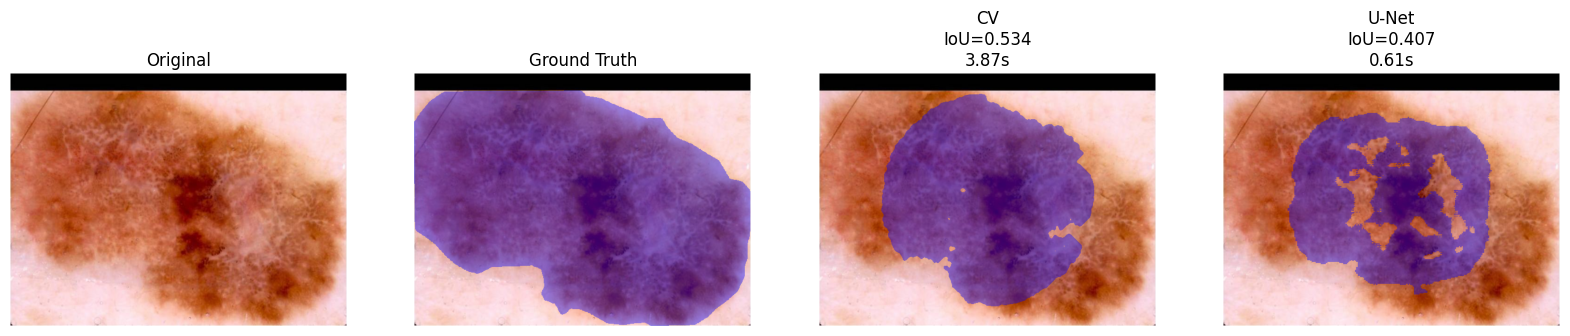

In [7]:
cv_overlay = overlay_mask(img, cv_mask)
unet_overlay = overlay_mask(img, unet_mask)
gt_overlay = overlay_mask(img, gt)

fig, ax = plt.subplots(1,4, figsize=(20,5))

ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(gt_overlay, cv2.COLOR_BGR2RGB))
ax[1].set_title("Ground Truth")
ax[1].axis("off")

ax[2].imshow(cv2.cvtColor(cv_overlay, cv2.COLOR_BGR2RGB))
ax[2].set_title(
    f"CV\nIoU={cv_iou:.3f}\n{cv_time:.2f}s"
)
ax[2].axis("off")

ax[3].imshow(cv2.cvtColor(unet_overlay, cv2.COLOR_BGR2RGB))
ax[3].set_title(
    f"U-Net\nIoU={unet_iou:.3f}\n{unet_time:.2f}s"
)
ax[3].axis("off")

plt.show()

## 2. Bảng so sánh (Dataframe)

In [2]:
df = pd.DataFrame(results)
display(df)


,Image,CV_IoU (%),CV_Time (s),UNet_IoU (%),UNet_Time (s)
0,ISIC_0000074.jpg,71.09,2.26,13.32,0.63
1,ISIC_0000077.jpg,83.97,2.26,0.25,0.60
2,ISIC_0000160.jpg,53.47,3.40,40.69,0.60


## 3. Chốt hạ vấn đề
- **U-Net:** Chạy cực nhanh, thích hợp cho hệ thống Real-time nhưng là "Hộp đen".
- **CV Truyền thống (Snakes + ABCD):** Chạy chậm hơn nhưng bù lại giải thích được hoàn toàn theo Y khoa (Explainability).
- **Kết luận:** Tùy thuộc vào yêu cầu của bệnh viện mà ta sẽ triển khai hệ thống nào (hoặc kết hợp Ensemble Majority Voting)!